# House Price Prediction

## Objective
Predict property prices using machine learning regression techniques.

## Business Value
Helps buyers estimate fair prices and enables sellers to optimize listing strategies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("house_prices.csv")
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.columns
df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [3]:
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [4]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [5]:
# Target variable
y = df['Price']

# Drop ID column (not useful for prediction)
df = df.drop('Property_ID', axis=1)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Property_Type'] = le.fit_transform(df['Property_Type'])

# Feature variables
X = df.drop('Price', axis=1)

print("Feature columns:", X.columns)
print("Target column: Price")

Feature columns: Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type'], dtype='object')
Target column: Price


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [8]:
print("Linear Regression MAE:",
      mean_absolute_error(y_test, lr_preds))

print("Linear Regression R2 Score:",
      r2_score(y_test, lr_preds))

Linear Regression MAE: 5411099.797604775
Linear Regression R2 Score: 0.7045684833622563


In [9]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [10]:
print("Random Forest MAE:",
      mean_absolute_error(y_test, rf_preds))

print("Random Forest R2 Score:",
      r2_score(y_test, rf_preds))

Random Forest MAE: 1514262.9166666667
Random Forest R2 Score: 0.9725036392753601


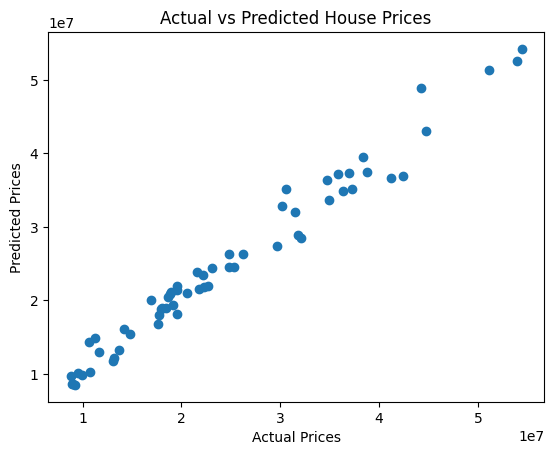

In [11]:

plt.scatter(y_test, rf_preds)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

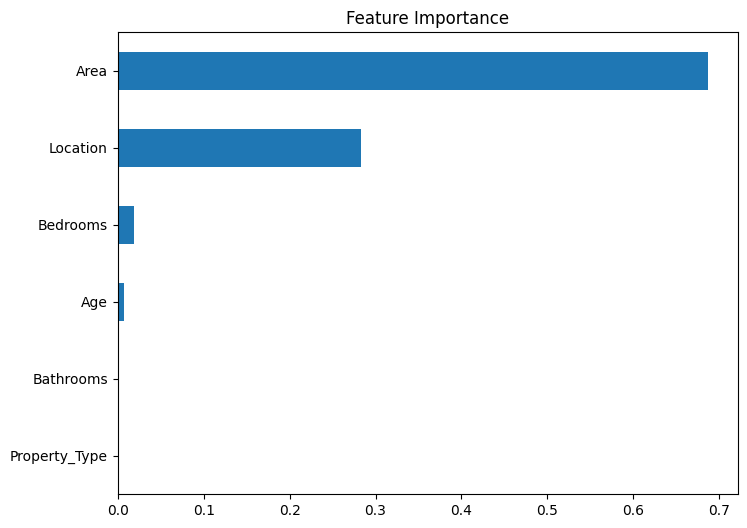

In [12]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

## Key Insights

Area is the strongest predictor of property price.

Location significantly influences valuation differences.

Bedrooms and bathrooms contribute positively to pricing trends.

Property age negatively impacts property value in many cases.

## Business Recommendations

Focus pricing strategies based on property size and location.

Use predictive pricing tools for accurate listing valuation.

Assist buyers with estimated fair market values.

In [14]:
pickle.dump(
    rf_model,
    open("house_price_model.pkl", "wb")
)